In [1]:
import numpy as np

def risolvi_minimi_quadrati_svd(X, y):
    U, S, Vt = np.linalg.svd(X, full_matrices=False)
    tol = np.max(S) * max(X.shape) * np.finfo(float).eps
    S_inv = np.array([1.0 / s if s > tol else 0.0 for s in S])
    alpha = Vt.T @ (S_inv * (U.T @ y))
    return alpha

In [2]:
d = 3
alpha = np.array([1.5, -2.0, 1.0, 0.5])
n = 20
sigma = 0.1

x = np.linspace(0, 1, n)
e = np.random.normal(loc=0, scale=sigma, size=n)

X = np.vander(x, d + 1, increasing=True)
y = X @ alpha + e

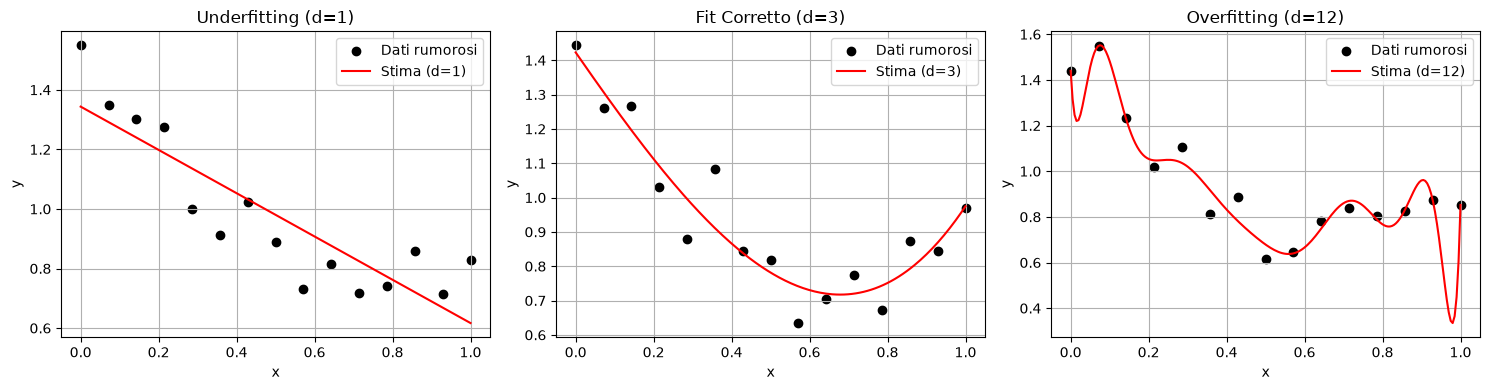

In [3]:
import matplotlib.pyplot as plt

np.random.seed(42)
d_vero = 3
alpha_vero = np.array([1.5, -2.0, 1.0, 0.5])
sigma = 0.1

configurazioni = [
    {"n": 15, "d_fit": 1, "titolo": "Underfitting (d=1)"},
    {"n": 15, "d_fit": 3, "titolo": "Fit Corretto (d=3)"},
    {"n": 15, "d_fit": 12, "titolo": "Overfitting (d=12)"}
]

plt.figure(figsize=(15, 4))

for idx, conf in enumerate(configurazioni):
    n = conf["n"]
    d_fit = conf["d_fit"]
    
    x = np.linspace(0, 1, n)
    X_gen = np.vander(x, d_vero + 1, increasing=True)
    y = X_gen @ alpha_vero + np.random.normal(0, sigma, n)
    
    X_fit = np.vander(x, d_fit + 1, increasing=True)
    U, S, Vt = np.linalg.svd(X_fit, full_matrices=False)
    tol = np.max(S) * max(X_fit.shape) * np.finfo(float).eps
    S_inv = np.array([1.0 / s if s > tol else 0.0 for s in S])
    alpha_est = Vt.T @ (S_inv * (U.T @ y))
    
    x_fine = np.linspace(0, 1, 200)
    X_fine = np.vander(x_fine, d_fit + 1, increasing=True)
    y_fine = X_fine @ alpha_est
    
    plt.subplot(1, 3, idx + 1)
    plt.scatter(x, y, color='black', label='Dati rumorosi')
    plt.plot(x_fine, y_fine, color='red', label=f'Stima (d={d_fit})')
    plt.title(conf["titolo"])
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

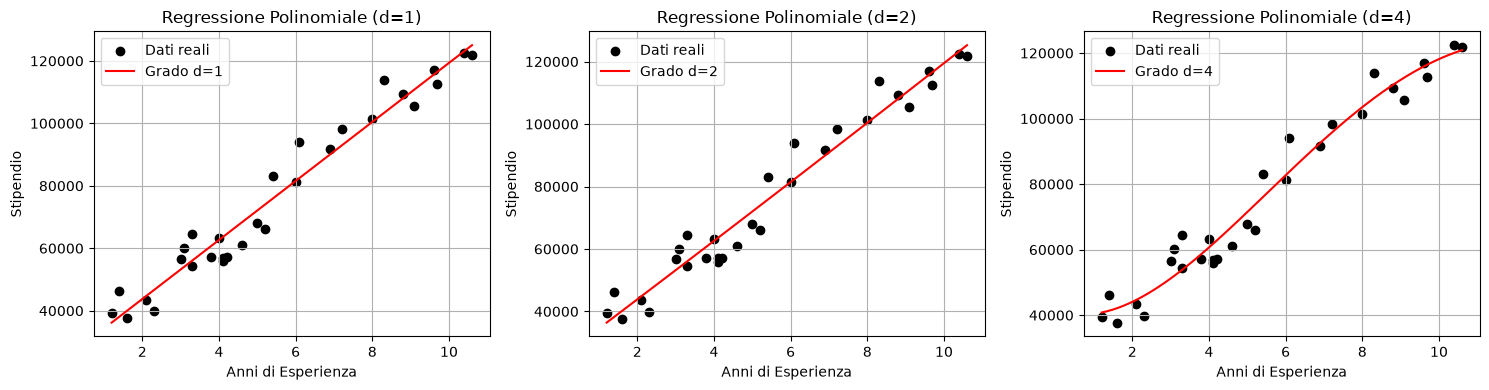

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('Salary_dataset.csv')

x = df['YearsExperience'].values
y = df['Salary'].values
n = len(x)

def risolvi_minimi_quadrati_svd(X, y):
    U, S, Vt = np.linalg.svd(X, full_matrices=False)
    tol = np.max(S) * max(X.shape) * np.finfo(float).eps
    S_inv = np.array([1.0 / s if s > tol else 0.0 for s in S])
    return Vt.T @ (S_inv * (U.T @ y))

gradi = [1, 2, 4]
plt.figure(figsize=(15, 4))

for idx, d in enumerate(gradi):
    X = np.vander(x, d + 1, increasing=True)
    alpha_est = risolvi_minimi_quadrati_svd(X, y)
    
    x_fine = np.linspace(min(x), max(x), 200)
    X_fine = np.vander(x_fine, d + 1, increasing=True)
    y_fine = X_fine @ alpha_est
    
    plt.subplot(1, 3, idx + 1)
    plt.scatter(x, y, color='black', label='Dati reali')
    plt.plot(x_fine, y_fine, color='red', label=f'Grado d={d}')
    plt.title(f'Regressione Polinomiale (d={d})')
    plt.xlabel('Anni di Esperienza')
    plt.ylabel('Stipendio')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

Regressione Lineare Semplice Polinomiale: Costruzione e Test del Modello: questo blocco iniziale implementa da zero il motore matematico per la regressione polinomiale, sfruttando la matrice di Vandermonde, e ne verifica il comportamento su due scenari distinti.

Motore Matematico (SVD): Definizione della funzione personalizzata risolvi_minimi_quadrati_svd per calcolare i coefficienti del polinomio in modo numericamente stabile, evitando l'inversione diretta della matrice.

Stress Test su Dati Sintetici: Generazione di un set di dati fittizi con l'aggiunta controllata di rumore gaussiano. Il modello viene applicato forzando tre gradi polinomiali diversi per dimostrare visivamente i concetti di underfitting ($d=1$), fit ottimale ($d=3$) e overfitting patologico ($d=12$).

Applicazione su Dati Reali (Kaggle): Importazione del dataset sugli stipendi. La stessa logica SVD viene applicata a un caso reale a due variabili (Anni di Esperienza vs Stipendio), testando la flessione della curva approssimante per $d=1, 2, 4$.

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('car_price.csv')

print("Colonne disponibili:", df.columns.tolist())

df_num = df.select_dtypes(include=['number'])


target_col = df_num.columns[-1] 

y = df_num[target_col]
X = df_num.drop(columns=[target_col])

modello = LinearRegression()
modello.fit(X, y)

y_pred = modello.predict(X)
print(f"Target utilizzato: {target_col}")
print(f"MSE: {mean_squared_error(y, y_pred):.4f}")
print(f"R^2 Score: {r2_score(y, y_pred):.4f}")

Colonne disponibili: ['CarName', 'carbody', 'drivewheel', 'enginelocation', 'fueltype', 'aspiration', 'doornumber', 'cylindernumber', 'enginetype', 'fuelsystem', 'symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price']
Target utilizzato: price
MSE: 9504328.2381
R^2 Score: 0.8477


In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

modello_base = LinearRegression()
modello_base.fit(X, y)
y_pred_base = modello_base.predict(X)
print(f"Modello Completo -> R^2: {r2_score(y, y_pred_base):.4f}, MSE: {mean_squared_error(y, y_pred_base):.4f}\n")

for col in X.columns:
    X_ridotto = X.drop(columns=[col])
    
    modello = LinearRegression()
    modello.fit(X_ridotto, y)
    
    y_pred = modello.predict(X_ridotto)
    r2 = r2_score(y, y_pred)
    mse = mean_squared_error(y, y_pred)
    
    print(f"Senza '{col}' -> R^2: {r2:.4f}, MSE: {mse:.4f}")

Modello Completo -> R^2: 0.8477, MSE: 9504328.2381

Senza 'symboling' -> R^2: 0.8471, MSE: 9539180.6261
Senza 'wheelbase' -> R^2: 0.8461, MSE: 9601305.4309
Senza 'carlength' -> R^2: 0.8453, MSE: 9655366.7068
Senza 'carwidth' -> R^2: 0.8448, MSE: 9682692.3679
Senza 'carheight' -> R^2: 0.8461, MSE: 9602838.2140
Senza 'curbweight' -> R^2: 0.8470, MSE: 9545931.9885
Senza 'enginesize' -> R^2: 0.7879, MSE: 13233344.3303
Senza 'boreratio' -> R^2: 0.8467, MSE: 9566767.4971
Senza 'stroke' -> R^2: 0.8348, MSE: 10309895.1779
Senza 'compressionratio' -> R^2: 0.8388, MSE: 10058206.8499
Senza 'horsepower' -> R^2: 0.8445, MSE: 9705444.4782
Senza 'peakrpm' -> R^2: 0.8386, MSE: 10072236.2066
Senza 'citympg' -> R^2: 0.8448, MSE: 9685838.9739
Senza 'highwaympg' -> R^2: 0.8461, MSE: 9603747.4968


Regressione Lineare Multipla:

In questa sezione il problema scala a più dimensioni. Si abbandona il calcolo manuale per delegare la risoluzione dei minimi quadrati alla libreria scikit-learn applicata al dataset automobilistico.

Preparazione dei Dati: Caricamento del dataset car_price.csv, filtraggio per isolare esclusivamente i dati numerici e separazione della colonna target (price) dal resto delle variabili (features).

Modello di Riferimento (Full Model): Addestramento di una regressione lineare multipla utilizzando il 100% delle caratteristiche fisiche e meccaniche disponibili simultaneamente, per registrare il punteggio $R^2$ e il MSE massimi raggiungibili.

Ricerca delle Variabili Chiave (Ablation Study): Costruzione di un ciclo iterativo automatizzato che esclude sistematicamente una singola caratteristica alla volta, riaddestra il modello e ricalcola gli errori. Questo processo identifica empiricamente il "peso" e l'importanza di ogni singola variabile sul calcolo del prezzo finale.